# Inter-scanner variability of FC matrices

In [1]:
library(reticulate)
library(tidyr)
library(MANOVA.RM)
library(irr)
library(effectsize)
use_python("/home/cprovins/miniconda3/envs/pymc_env/bin/python", required = TRUE)

Loading required package: lpSolve



## Load the FC matrices

We load the functional connectivity (FC) matrices using Python code so we can conveniently leverage our custom configuration for PyBIDS. Which scanner was the participant scanned on is encoded in the last three digits of the session number (Prisma=060, Vida=034, VidaFit=030).

In [2]:
py_run_string('
import re
import pandas as pd
from pathlib import Path
from bids.layout import BIDSLayout, BIDSLayoutIndexer, add_config_paths

# Define filtering parameters
metric = "sparseinversecovariance"
atlas_dimension = "64"
fd_threshold = 0.5
fdthresh_str = str(fd_threshold).replace(".", "")

# Define paths
code_path = Path("/data/code/hcph-sops/")
fc_path = Path(f"/data/derivatives/functional_connectivity_defaultparams_generalization")

# Initialize the BIDS layout
config_path = code_path / "code/bids/indexer.json"
try:
    add_config_paths(hcph=config_path)
except ValueError as e:
    if "Configuration hcph already exists" in str(e):
        print("Configuration hcph already exists, skipping add_config_paths.")
    else:
        raise e

_indexer = BIDSLayoutIndexer(
    config_filename=config_path,
    index_metadata=False,
    validate=False,
)       
layout = BIDSLayout(fc_path, config="hcph", indexer=_indexer, validate=False)

# Load files
entities_base = {
    "subject": "001",
    "task": "rest",
    "measure": metric,
    "scale": atlas_dimension,
    "fd_threshold": fdthresh_str,
}
# Get functional connectivity files
files = layout.get(**entities_base, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files) == 36, f"Expected 36 FC matrices, got {len(files)}"
df_fc = pd.DataFrame({"filename": files})

# Retrieve which scanner was used for each session (encoded in the last three digits of the session ID)
df_fc["session"] = df_fc["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)

def extract_scanner(session):
    scanner_codes = {"060": "prisma", "034": "vida", "030": "vidafit"}
    code = session[-3:]
    return scanner_codes.get(code, "unknown")

df_fc["scanner"] = df_fc["session"].apply(extract_scanner)
df_fc["repetition"] = df_fc["session"].str[1:3].astype(int)
')

In [3]:
# Load the panda DataFrame into R
df_fc <- as.data.frame(py$df_fc)

## Repeated-measures MANOVA
### Prepare the dataframe for inputting into rm-MANOVA

We add each value from the upper triangle of the functional connectivity (FC) matrix as a separate column in the dataframe. Since the FC matrix is symmetric, retaining only the upper triangle is sufficient. This transformation is necessary because the implementation of repeated-measures MANOVA (rm-MANOVA) requires each variable to be explicitly specified as a column to write the formula determining the dependent and independent variables of the model.

In [4]:
# Load all FC matrices and add them flattened to the dataframe
for (i in seq_len(nrow(df_fc))) {
    tsv_file <- df_fc$filename[i]
    mat <- as.matrix(read.table(tsv_file, header = FALSE, sep = "\t"))
    # Negate the matrix to get partial correlations
    mat <- -mat
    # Flatten the upper triangle of the matrix (excluding diagonal)
    flat <- mat[upper.tri(mat, diag = FALSE)]
    col_names <- paste0("edge", seq_along(flat))
    # Add values to the dataframe
    for (j in seq_along(flat)) {
        df_fc[i, col_names[j]] <- flat[j]
    }
}
# Remove the filename column as it is no longer needed
df_fc$filename <- NULL

df_fc$scanner <- as.factor(df_fc$scanner)
df_fc$repetition <- as.factor(df_fc$repetition)
head(df_fc)

,session,scanner,repetition,edge1,edge2,edge3,edge4,edge5,edge6,edge7,⋯,edge2007,edge2008,edge2009,edge2010,edge2011,edge2012,edge2013,edge2014,edge2015,edge2016
,<chr>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,20101060,prisma,1,2.306907e-06,6.016816e-07,8.431722e-02,7.261132e-02,-2.158522e-07,-2.159536e-06,3.599130e-06,⋯,-4.719922e-17,-5.050312e-17,-4.626155e-17,3.922101e-17,6.661655e-03,-3.762182e-17,-9.308938e-18,7.979728e-17,3.990927e-02,7.862472e-17
2,20102030,vidafit,1,-1.466132e-05,-3.299349e-06,1.600184e-02,6.238332e-02,-1.257111e-05,-3.121985e-06,-6.914635e-07,⋯,-4.857226e-17,-4.931087e-17,-2.579046e-17,-2.461139e-17,1.205857e-01,8.887884e-17,-1.260848e-16,1.787882e-17,-6.565003e-17,3.392830e-17
3,20103034,vida,1,-5.360448e-07,9.460537e-06,7.644690e-02,1.803744e-05,-5.256976e-07,1.048499e-05,4.556559e-06,⋯,-2.584738e-16,-2.369117e-16,1.460420e-16,-2.775558e-17,1.205608e-01,2.558717e-17,1.463598e-16,-2.341877e-17,2.634392e-02,-5.116059e-17
4,20201060,prisma,2,7.445476e-07,1.137778e-06,2.195331e-06,-1.276011e-05,-3.677465e-07,-2.891751e-06,-6.208714e-08,⋯,-2.652429e-18,-1.354266e-17,-2.094097e-17,-8.477603e-18,-4.872733e-17,7.362619e-17,-7.102195e-17,-5.400568e-17,-6.712262e-17,3.821447e-17
5,20202030,vidafit,2,-3.308814e-06,-2.426205e-07,1.237668e-02,2.280166e-05,-9.163955e-07,9.076212e-07,7.349608e-06,⋯,3.948858e-02,-1.377322e-17,-1.046053e-16,5.869540e-17,8.182741e-02,-4.160738e-17,-3.338092e-18,-5.084564e-17,1.179870e-16,-1.748007e-16
6,20203034,vida,2,-6.932686e-07,2.698354e-02,4.206261e-06,4.808618e-04,-1.014679e-06,-1.332279e-07,5.983490e-06,⋯,2.195855e-02,-1.087758e-16,-2.329135e-16,1.483084e-16,6.187289e-17,-4.030640e-17,5.439214e-17,-1.054899e-17,7.824223e-18,-4.112101e-17


### Construct the formula by concatenating the column names that correspond to edge value

In [5]:
#Construct formula
dep_var <- ''
col_names <- colnames(df_fc)
#Remove non-iqms column names
edge_keys <- col_names[c(-1,-2,-3)]
for (key in edge_keys){
    dep_var <- paste(dep_var, sprintf('%s +',key))
}
dep_var = substring(dep_var,1, nchar(dep_var)-2)

my_formula <- as.formula(paste(dep_var, " ~ scanner + repetition"))
my_formula

edge1 + edge2 + edge3 + edge4 + edge5 + edge6 + edge7 + edge8 + 
    edge9 + edge10 + edge11 + edge12 + edge13 + edge14 + edge15 + 
    edge16 + edge17 + edge18 + edge19 + edge20 + edge21 + edge22 + 
    edge23 + edge24 + edge25 + edge26 + edge27 + edge28 + edge29 + 
    edge30 + edge31 + edge32 + edge33 + edge34 + edge35 + edge36 + 
    edge37 + edge38 + edge39 + edge40 + edge41 + edge42 + edge43 + 
    edge44 + edge45 + edge46 + edge47 + edge48 + edge49 + edge50 + 
    edge51 + edge52 + edge53 + edge54 + edge55 + edge56 + edge57 + 
    edge58 + edge59 + edge60 + edge61 + edge62 + edge63 + edge64 + 
    edge65 + edge66 + edge67 + edge68 + edge69 + edge70 + edge71 + 
    edge72 + edge73 + edge74 + edge75 + edge76 + edge77 + edge78 + 
    edge79 + edge80 + edge81 + edge82 + edge83 + edge84 + edge85 + 
    edge86 + edge87 + edge88 + edge89 + edge90 + edge91 + edge92 + 
    edge93 + edge94 + edge95 + edge96 + edge97 + edge98 + edge99 + 
    edge100 + edge101 + edge102 + edge103 + edge104 

### Run the rm-MANOVA

In [6]:
fit <- multRM(my_formula, data = df_fc, subject = 'session', within = 'repetition')
summary(fit)

ERROR: Error in prepare.data(formula, data, subject, within): The number of subjects (36) times the 
  number of within-subject factor levels (12) does not equal
  the total number of observations (36). 
  Check for missing values in the data.


## Intra-class correlation coefficient (ICC)

In [ ]:
icc_results <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

for (edge in edge_keys) {
    # Keep only the edge and session columns
    df_icc <- df_fc[, c( "scanner", edge)]
    df_icc <- pivot_wider(df_icc, names_from = scanner, values_from = edge, values_fn = list)
    df_icc <- unnest(df_icc, cols = c(prisma, vida, vidafit))
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
    icc_results <- rbind(icc_results, data.frame(edge = edge, ICC = icc_val))
}
icc_results


[1] 0.04796495
[1] -0.04708805
[1] -0.05694832
[1] -0.1748115
[1] 0.04109561
[1] -0.001612235
[1] -0.02717064
[1] 0.1509714
[1] -0.1557382
[1] -0.09237696
[1] 0.3360808
[1] 0.006725615
[1] -0.06608497
[1] 0.174812
[1] 0.02014929
[1] -0.1077075
[1] 0.002800499
[1] -0.0444907
[1] 1.583706e-05
[1] -0.2297746
[1] -0.2085344
[1] -0.06534477
[1] -0.3098062
[1] -0.1061106
[1] 0.00021123
[1] 0.0001419543
[1] 0.0006707104
[1] -0.03904908
[1] 0.2092374
[1] -0.2440074
[1] -0.2002412
[1] 0.158603
[1] 0.0360906
[1] -0.04512235
[1] -0.1663514
[1] -0.06316756
[1] 0.0008100796
[1] -0.260511
[1] -0.003015245
[1] 0.001374586
[1] 0.05442568
[1] -0.1038786
[1] -0.1202157
[1] -0.03493015
[1] -0.03103678
[1] 0.02399644
[1] -0.3266262
[1] -0.000120994
[1] -0.03962296
[1] -0.004819888
[1] -0.01091073
[1] -0.007218143
[1] 0.003265377
[1] 0.2660266
[1] 0.1557717
[1] 0.000673123
[1] -0.07531187
[1] -0.07334523
[1] 0.0004072321
[1] -0.04162503
[1] -0.1295797
[1] 0.03633667
[1] -0.05595715
[1] -0.07002055
[1] -0.2

edge,ICC
<chr>,<dbl>
edge1,4.796495e-02
edge2,-4.708805e-02
edge3,-5.694832e-02
edge4,-1.748115e-01
edge5,4.109561e-02
edge6,-1.612235e-03
edge7,-2.717064e-02
edge8,1.509714e-01
edge9,-1.557382e-01


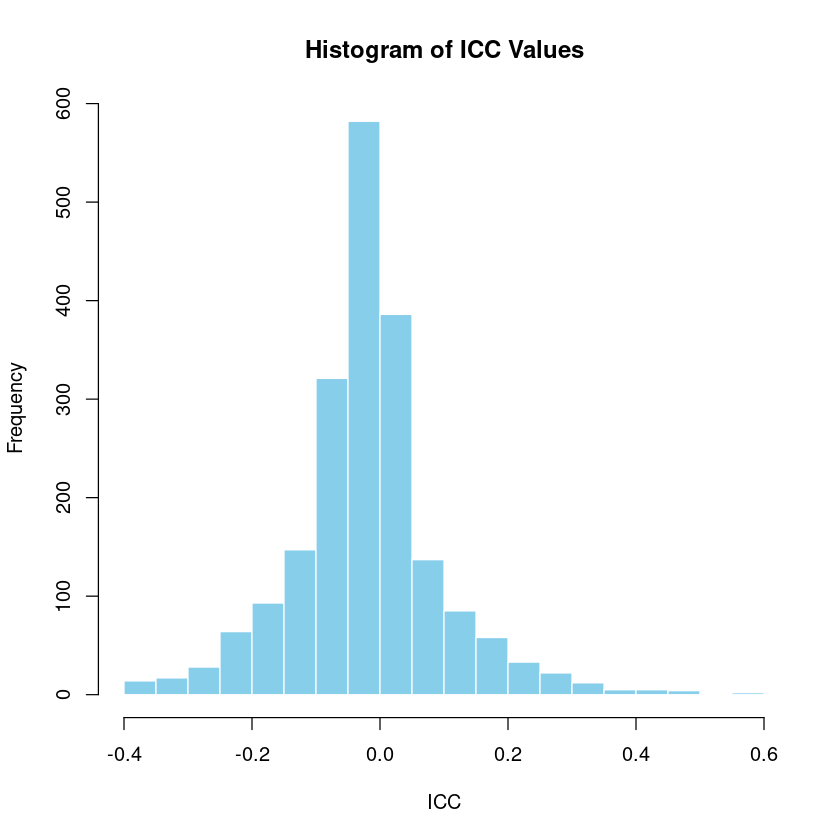

In [12]:
hist(icc_results$ICC, breaks = 20, main = "Histogram of ICC Values", xlab = "ICC", col = "skyblue", border = "white")

In [13]:
df <- df_fc[, c( "scanner", "edge1")]
print(df)
df <- tidyr::pivot_wider(df, names_from = scanner, values_from = edge1, values_fn = list)
df <- tidyr::unnest(df, cols = c(prisma, vida, vidafit))
df <- df[,c("prisma")]
print(df)
icc(df, model = "oneway", type = "agreement", unit = "single")
df

   scanner         edge1
1   prisma  2.306907e-06
2  vidafit -1.466132e-05
3     vida -5.360448e-07
4   prisma  7.445476e-07
5  vidafit -3.308814e-06
6     vida -6.932686e-07
7   prisma -1.847560e-07
8     vida -1.079332e-05
9  vidafit -6.934294e-06
10 vidafit -2.023367e-06
11    vida -1.428846e-06
12  prisma  3.818046e-07
13 vidafit  2.718948e-07
14    vida -4.385628e-06
15  prisma -1.462140e-08
16    vida -1.444526e-06
17  prisma -1.781449e-07
18 vidafit -2.096006e-06
19    vida -1.813064e-06
20 vidafit -7.142645e-06
21  prisma -6.100738e-09
22 vidafit  6.558012e-06
23    vida -1.212758e-06
24  prisma -5.922438e-06
25 vidafit -2.380660e-05
26  prisma -2.779550e-06
27    vida -2.644742e-05
28 vidafit -1.628870e-07
29  prisma -4.107528e-07
30    vida -2.713741e-06
31    vida  6.069144e-07
32  prisma  2.611806e-04
33 vidafit  1.075606e-06
34 vidafit  2.996492e-06
35    vida -1.769198e-06
36  prisma -3.977376e-07
# A tibble: 12 × 1
     prisma
      <dbl>
 1  2.31e-6
 2  7.45e-7
 3 -1.85

Warning message in qf(1 - alpha/2, ns - 1, ns * (nr - 1)):
“NaNs produced”
Warning message in qf(1 - alpha/2, ns * (nr - 1), ns - 1):
“NaNs produced”


 Single Score Intraclass Correlation

   Model: oneway 
   Type : agreement 

   Subjects = 12 
     Raters = 1 
     ICC(1) = NA

 F-Test, H0: r0 = 0 ; H1: r0 > 0 
    F(11,0) = NA , p = NA 

 95%-Confidence Interval for ICC Population Values:
  NA < ICC < NA

prisma
<dbl>
2.306907e-06
7.445476e-07
-1.847560e-07
3.818046e-07
-1.462140e-08
-1.781449e-07
-6.100738e-09
-5.922438e-06
-2.779550e-06
